In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
import os

os.makedirs(r"c:\Users\deepk\mf_analytics\charts", exist_ok=True)

nav_df = pd.read_csv(r"c:\Users\deepk\mf_analytics\data\processed\nav_history_clean.csv")
fund_df = pd.read_csv(r"c:\Users\deepk\mf_analytics\data\processed\fund_master_clean.csv")

merged_df = nav_df.merge(fund_df[["amfi_code", "scheme_name", "category", "expense_ratio_pct"]], on="amfi_code", how="left")
merged_df["date"] = pd.to_datetime(merged_df["date"])
merged_df = merged_df.sort_values(["scheme_name", "date"])

print(merged_df.shape)
print(merged_df["scheme_name"].nunique(), "schemes")
print(merged_df.head(3))

(46000, 6)
40 schemes
      amfi_code       date       nav  \
3450     101206 2022-01-03  305.0996   
3451     101206 2022-01-04  305.4514   
3452     101206 2022-01-05  306.6324   

                                        scheme_name category  \
3450  ABSL Frontline Equity Fund - Regular - Growth   Equity   
3451  ABSL Frontline Equity Fund - Regular - Growth   Equity   
3452  ABSL Frontline Equity Fund - Regular - Growth   Equity   

      expense_ratio_pct  
3450                1.6  
3451                1.6  
3452                1.6  


## Compute Daily Returns

In [2]:
merged_df["daily_return"] = (
    merged_df.groupby("scheme_name")["nav"]
    .pct_change()
)

returns_df = merged_df.dropna(subset=["daily_return"]).copy()

print(returns_df["daily_return"].describe())
print(f"\nNull returns remaining: {returns_df['daily_return'].isna().sum()}")

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

Null returns remaining: 0


## Compute CAGR

In [3]:
def compute_cagr(df, years):
    end_date = df["date"].max()
    start_date = end_date - pd.DateOffset(years=years)
    
    window = df[df["date"] >= start_date]
    
    result = window.groupby("scheme_name").apply(
        lambda x: (x.loc[x["date"].idxmax(), "nav"] / 
                   x.loc[x["date"].idxmin(), "nav"]) ** (1/years) - 1
    ).reset_index()
    result.columns = ["scheme_name", f"cagr_{years}yr"]
    return result

cagr_1yr = compute_cagr(returns_df, 1)
cagr_3yr = compute_cagr(returns_df, 3)

cagr_df = cagr_1yr.merge(cagr_3yr, on="scheme_name")
cagr_df["cagr_1yr_pct"] = (cagr_df["cagr_1yr"] * 100).round(2)
cagr_df["cagr_3yr_pct"] = (cagr_df["cagr_3yr"] * 100).round(2)

print(cagr_df[["scheme_name", "cagr_1yr_pct", "cagr_3yr_pct"]].sort_values("cagr_3yr_pct", ascending=False))

                                          scheme_name  cagr_1yr_pct  \
5                 Axis Midcap Fund - Regular - Growth         22.26   
25      Mirae Asset Large Cap Fund - Regular - Growth         20.36   
15          ICICI Pru Bluechip Fund - Direct - Growth         13.06   
11  HDFC Mid-Cap Opportunities Fund - Regular - Gr...         53.23   
18           ICICI Pru Midcap Fund - Regular - Growth         29.60   
33          SBI Bluechip Fund - Regular Plan - Growth         60.44   
22             Kotak Flexicap Fund - Regular - Growth         26.66   
26      Mirae Asset Tax Saver Fund - Regular - Growth         39.75   
0       ABSL Frontline Equity Fund - Regular - Growth         47.92   
8               DSP Small Cap Fund - Regular - Growth         65.14   
7                  DSP Midcap Fund - Regular - Growth         21.48   
36         SBI Small Cap Fund - Regular Plan - Growth         82.78   
37              UTI Flexi Cap Fund - Regular - Growth         13.58   
30    

C:\Users\deepk\AppData\Local\Temp\ipykernel_18024\806966333.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = window.groupby("scheme_name").apply(
C:\Users\deepk\AppData\Local\Temp\ipykernel_18024\806966333.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = window.groupby("scheme_name").apply(


## Sharpe Ratio

In [4]:
Rf_daily = 0.065 / 252  # 6.5% annual risk-free rate

sharpe_df = (
    returns_df.groupby("scheme_name")["daily_return"]
    .agg(
        mean_return="mean",
        std_return="std"
    )
    .reset_index()
)

sharpe_df["sharpe_ratio"] = (
    (sharpe_df["mean_return"] - Rf_daily) / sharpe_df["std_return"] * np.sqrt(252)
).round(4)

sharpe_df = sharpe_df.sort_values("sharpe_ratio", ascending=False)
sharpe_df["sharpe_rank"] = range(1, len(sharpe_df) + 1)

print(sharpe_df[["scheme_name", "sharpe_ratio", "sharpe_rank"]].to_string())

                                              scheme_name  sharpe_ratio  sharpe_rank
25          Mirae Asset Large Cap Fund - Regular - Growth        1.4483            1
22                 Kotak Flexicap Fund - Regular - Growth        1.3067            2
26          Mirae Asset Tax Saver Fund - Regular - Growth        1.2349            3
33              SBI Bluechip Fund - Regular Plan - Growth        1.2083            4
18               ICICI Pru Midcap Fund - Regular - Growth        1.1801            5
7                      DSP Midcap Fund - Regular - Growth        1.1321            6
11     HDFC Mid-Cap Opportunities Fund - Regular - Growth        1.0937            7
30         Nippon India Large Cap Fund - Regular - Growth        1.0817            8
0           ABSL Frontline Equity Fund - Regular - Growth        1.0272            9
15              ICICI Pru Bluechip Fund - Direct - Growth        1.0265           10
5                     Axis Midcap Fund - Regular - Growth        

## Sortino Ratio

In [5]:
def downside_std(returns):
    negative_returns = returns[returns < 0]
    return negative_returns.std()

Rf_daily = 0.065 / 252

sortino_df = (
    returns_df.groupby("scheme_name")["daily_return"]
    .agg(
        mean_return="mean",
        downside_std=downside_std
    )
    .reset_index()
)

sortino_df["sortino_ratio"] = (
    (sortino_df["mean_return"] - Rf_daily) / sortino_df["downside_std"] * np.sqrt(252)
).round(4)

sortino_df = sortino_df.sort_values("sortino_ratio", ascending=False)
sortino_df["sortino_rank"] = range(1, len(sortino_df) + 1)

print(sortino_df[["scheme_name", "sortino_ratio", "sortino_rank"]].to_string())

                                              scheme_name  sortino_ratio  sortino_rank
25          Mirae Asset Large Cap Fund - Regular - Growth         2.3856             1
22                 Kotak Flexicap Fund - Regular - Growth         2.3643             2
26          Mirae Asset Tax Saver Fund - Regular - Growth         2.1469             3
33              SBI Bluechip Fund - Regular Plan - Growth         2.1403             4
18               ICICI Pru Midcap Fund - Regular - Growth         2.0294             5
7                      DSP Midcap Fund - Regular - Growth         1.8751             6
30         Nippon India Large Cap Fund - Regular - Growth         1.8501             7
11     HDFC Mid-Cap Opportunities Fund - Regular - Growth         1.8291             8
15              ICICI Pru Bluechip Fund - Direct - Growth         1.8053             9
0           ABSL Frontline Equity Fund - Regular - Growth         1.7996            10
5                     Axis Midcap Fund - Re

## Alpha and Beta

In [6]:
benchmark = returns_df[
    returns_df["scheme_name"] == "UTI Nifty 50 Index Fund - Regular - Growth"
][["date", "daily_return"]].rename(columns={"daily_return": "benchmark_return"})

print(benchmark.shape)
print(benchmark.head(3))

(1149, 2)
           date  benchmark_return
6901 2022-01-04          0.011122
6902 2022-01-05         -0.007878
6903 2022-01-06          0.015277


In [7]:
alpha_beta_records = []

for scheme, group in returns_df.groupby("scheme_name"):
    merged = group[["date", "daily_return"]].merge(benchmark, on="date", how="inner")
    
    if len(merged) < 30:  # skip if insufficient data
        continue
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )
    
    alpha_beta_records.append({
        "scheme_name": scheme,
        "alpha": round(intercept * 252, 4),  # annualized
        "beta": round(slope, 4),
        "r_squared": round(r_value**2, 4)
    })

alpha_beta_df = pd.DataFrame(alpha_beta_records)
alpha_beta_df = alpha_beta_df.sort_values("alpha", ascending=False)
alpha_beta_df["alpha_rank"] = range(1, len(alpha_beta_df) + 1)

print(alpha_beta_df.to_string())

                                              scheme_name   alpha    beta  r_squared  alpha_rank
8                   DSP Small Cap Fund - Regular - Growth  0.3001  0.0046     0.0000           1
36             SBI Small Cap Fund - Regular Plan - Growth  0.2956  0.0415     0.0004           2
18               ICICI Pru Midcap Fund - Regular - Growth  0.2916  0.0060     0.0000           3
11     HDFC Mid-Cap Opportunities Fund - Regular - Growth  0.2807 -0.0505     0.0012           4
26          Mirae Asset Tax Saver Fund - Regular - Growth  0.2778  0.0323     0.0006           5
22                 Kotak Flexicap Fund - Regular - Growth  0.2751 -0.0144     0.0001           6
7                      DSP Midcap Fund - Regular - Growth  0.2693 -0.0201     0.0002           7
25          Mirae Asset Large Cap Fund - Regular - Growth  0.2642  0.0373     0.0011           8
5                     Axis Midcap Fund - Regular - Growth  0.2490  0.0573     0.0014           9
15              ICICI Pru Blue

## Maximum Drawdown

In [8]:
def max_drawdown(nav_series):
    running_max = nav_series.cummax()
    drawdown = nav_series / running_max - 1
    return drawdown.min()

def drawdown_dates(group):
    running_max = group["nav"].cummax()
    drawdown = group["nav"] / running_max - 1
    min_idx = drawdown.idxmin()
    
    # peak is last time running_max was hit before trough
    trough_date = group.loc[min_idx, "date"]
    peak_date = group.loc[group["date"] <= trough_date]["nav"].idxmax()
    peak_date = group.loc[peak_date, "date"]
    
    return pd.Series({
        "max_drawdown": round(drawdown.min() * 100, 2),
        "peak_date": peak_date,
        "trough_date": trough_date
    })

drawdown_df = (
    merged_df.groupby("scheme_name")
    .apply(drawdown_dates)
    .reset_index()
)

drawdown_df = drawdown_df.sort_values("max_drawdown")
drawdown_df["dd_rank"] = range(1, len(drawdown_df) + 1)

print(drawdown_df[["scheme_name", "max_drawdown", "peak_date", "trough_date"]].to_string())

                                              scheme_name  max_drawdown  peak_date trough_date
35              SBI Small Cap Fund - Direct Plan - Growth        -52.57 2023-01-17  2025-10-28
6                  Axis Small Cap Fund - Regular - Growth        -51.68 2025-05-22  2026-05-11
2                  ABSL Small Cap Fund - Regular - Growth        -35.45 2024-11-21  2026-05-11
8                   DSP Small Cap Fund - Regular - Growth        -31.17 2024-05-03  2025-01-03
36             SBI Small Cap Fund - Regular Plan - Growth        -28.71 2024-08-28  2025-05-14
38                    UTI Mid Cap Fund - Regular - Growth        -28.00 2025-01-07  2026-04-27
14              HDFC Top 100 Fund - Regular Plan - Growth        -24.73 2022-03-30  2022-09-15
21          Kotak Emerging Equity Fund - Regular - Growth        -24.00 2023-11-09  2024-10-17
31         Nippon India Small Cap Fund - Regular - Growth        -23.34 2025-04-09  2026-02-20
3                    Axis Bluechip Fund - Direct -

C:\Users\deepk\AppData\Local\Temp\ipykernel_18024\132580876.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(drawdown_dates)


## Fund Scorecard

In [10]:
# Pull expense ratio from fund_df
expense_df = fund_df[["scheme_name", "expense_ratio_pct"]].copy()

# Merge all metrics
scorecard = (
    cagr_df[["scheme_name", "cagr_3yr_pct"]]
    .merge(sharpe_df[["scheme_name", "sharpe_ratio", "sharpe_rank"]], on="scheme_name")
    .merge(alpha_beta_df[["scheme_name", "alpha", "alpha_rank"]], on="scheme_name")
    .merge(drawdown_df[["scheme_name", "max_drawdown", "dd_rank"]], on="scheme_name")
    .merge(expense_df, on="scheme_name")
)

# Compute remaining ranks
scorecard["cagr_rank"] = scorecard["cagr_3yr_pct"].rank(ascending=False).astype(int)
scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(ascending=True).astype(int)  # lower = better

n = len(scorecard)

# Normalize ranks to 0-100 (rank 1 = 100, rank n = 0)
def rank_to_score(rank_series, n):
    return ((n - rank_series) / (n - 1) * 100).round(2)

scorecard["score_cagr"]    = rank_to_score(scorecard["cagr_rank"], n)
scorecard["score_sharpe"]  = rank_to_score(scorecard["sharpe_rank"], n)
scorecard["score_alpha"]   = rank_to_score(scorecard["alpha_rank"], n)
scorecard["score_expense"] = rank_to_score(scorecard["expense_rank"], n)
scorecard["score_dd"]      = rank_to_score(scorecard["dd_rank"], n)

# Composite score
scorecard["composite_score"] = (
    0.30 * scorecard["score_cagr"] +
    0.25 * scorecard["score_sharpe"] +
    0.20 * scorecard["score_alpha"] +
    0.15 * scorecard["score_expense"] +
    0.10 * scorecard["score_dd"]
).round(2)

scorecard = scorecard.sort_values("composite_score", ascending=False)
scorecard["final_rank"] = range(1, len(scorecard) + 1)

print(scorecard[["scheme_name", "composite_score", "final_rank"]].to_string())

                                              scheme_name  composite_score  final_rank
18               ICICI Pru Midcap Fund - Regular - Growth            84.10           1
11     HDFC Mid-Cap Opportunities Fund - Regular - Growth            81.03           2
5                     Axis Midcap Fund - Regular - Growth            80.26           3
25          Mirae Asset Large Cap Fund - Regular - Growth            78.98           4
22                 Kotak Flexicap Fund - Regular - Growth            77.18           5
15              ICICI Pru Bluechip Fund - Direct - Growth            76.66           6
8                   DSP Small Cap Fund - Regular - Growth            75.00           7
36             SBI Small Cap Fund - Regular Plan - Growth            73.97           8
26          Mirae Asset Tax Saver Fund - Regular - Growth            72.95           9
33              SBI Bluechip Fund - Regular Plan - Growth            72.05          10
7                      DSP Midcap Fund - Re

In [11]:
scorecard.to_csv(
    r"c:\Users\deepk\mf_analytics\data\processed\fund_scorecard.csv",
    index=False
)

alpha_beta_df.to_csv(
    r"c:\Users\deepk\mf_analytics\data\processed\alpha_beta.csv",
    index=False
)

print("fund_scorecard.csv saved")
print("alpha_beta.csv saved")

fund_scorecard.csv saved
alpha_beta.csv saved


## Top 5 Funds

In [12]:
top5_schemes = scorecard.head(5)["scheme_name"].tolist()
benchmark_name = "UTI Nifty 50 Index Fund - Regular - Growth"

# Include benchmark in plot
plot_schemes = top5_schemes + [benchmark_name]
plot_schemes = list(set(plot_schemes))  # avoid duplicate if benchmark is in top 5

print("Top 5 funds:")
for s in top5_schemes:
    print(" -", s)

Top 5 funds:
 - ICICI Pru Midcap Fund - Regular - Growth
 - HDFC Mid-Cap Opportunities Fund - Regular - Growth
 - Axis Midcap Fund - Regular - Growth
 - Mirae Asset Large Cap Fund - Regular - Growth
 - Kotak Flexicap Fund - Regular - Growth


## Filter 3 Year Window + Normalize

In [13]:
end_date = merged_df["date"].max()
start_date = end_date - pd.DateOffset(years=3)

plot_df = merged_df[
    (merged_df["scheme_name"].isin(plot_schemes)) &
    (merged_df["date"] >= start_date)
].copy()

# Normalize NAV to 100 at start date per fund
def normalize_nav(group):
    group = group.sort_values("date")
    group["nav_normalized"] = group["nav"] / group["nav"].iloc[0] * 100
    return group

plot_df = plot_df.groupby("scheme_name", group_keys=False).apply(normalize_nav)

print(plot_df["scheme_name"].nunique(), "funds in chart")
print(plot_df.head(3))

6 funds in chart
       amfi_code       date      nav                          scheme_name  \
18765     119094 2023-05-29  82.6510  Axis Midcap Fund - Regular - Growth   
18766     119094 2023-05-30  82.2439  Axis Midcap Fund - Regular - Growth   
18767     119094 2023-05-31  80.6748  Axis Midcap Fund - Regular - Growth   

      category  expense_ratio_pct  daily_return  nav_normalized  
18765   Equity               1.38     -0.005845      100.000000  
18766   Equity               1.38     -0.004926       99.507447  
18767   Equity               1.38     -0.019079       97.608982  


C:\Users\deepk\AppData\Local\Temp\ipykernel_18024\1984098642.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  plot_df = plot_df.groupby("scheme_name", group_keys=False).apply(normalize_nav)


## Plot Benchmark Comparison

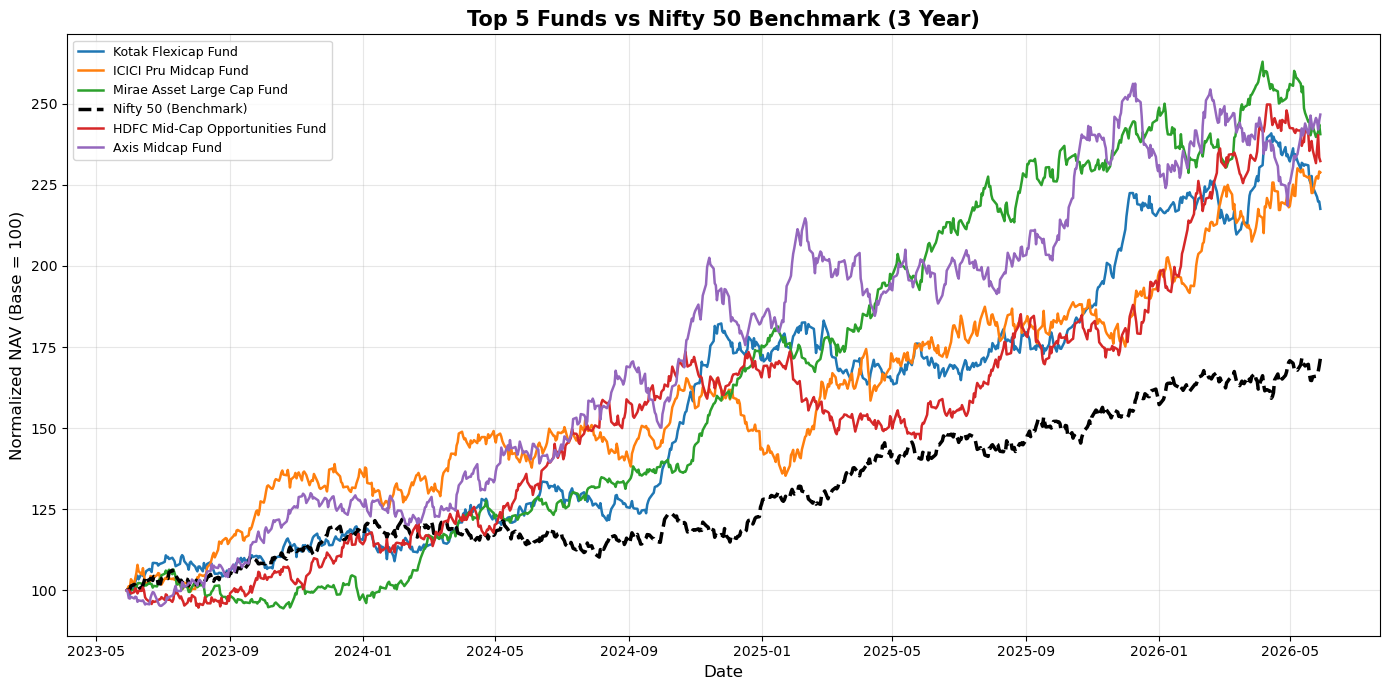

In [14]:
fig, ax = plt.subplots(figsize=(14, 7))

for scheme in plot_schemes:
    subset = plot_df[plot_df["scheme_name"] == scheme].sort_values("date")
    
    if scheme == benchmark_name:
        ax.plot(subset["date"], subset["nav_normalized"],
                label="Nifty 50 (Benchmark)", color="black",
                linewidth=2.5, linestyle="--")
    else:
        ax.plot(subset["date"], subset["nav_normalized"],
                label=scheme.split(" - ")[0],  # shortened name
                linewidth=1.8)

ax.set_title("Top 5 Funds vs Nifty 50 Benchmark (3 Year)", fontsize=15, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Normalized NAV (Base = 100)", fontsize=12)
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r"c:\Users\deepk\mf_analytics\charts\chart_13_benchmark_comparison.png", dpi=150)
plt.show()

In [15]:
benchmark_returns = returns_df[
    returns_df["scheme_name"] == benchmark_name
][["date", "daily_return"]].rename(columns={"daily_return": "benchmark_return"})

tracking_error_records = []

for scheme in top5_schemes:
    fund_returns = returns_df[returns_df["scheme_name"] == scheme][["date", "daily_return"]]
    merged_te = fund_returns.merge(benchmark_returns, on="date", how="inner")
    
    active_return = merged_te["daily_return"] - merged_te["benchmark_return"]
    te = active_return.std() * np.sqrt(252)
    
    tracking_error_records.append({
        "scheme_name": scheme,
        "tracking_error_pct": round(te * 100, 2)
    })

te_df = pd.DataFrame(tracking_error_records).sort_values("tracking_error_pct")
print(te_df.to_string())

                                          scheme_name  tracking_error_pct
3       Mirae Asset Large Cap Fund - Regular - Growth               18.81
4              Kotak Flexicap Fund - Regular - Growth               20.54
2                 Axis Midcap Fund - Regular - Growth               22.86
0            ICICI Pru Midcap Fund - Regular - Growth               23.13
1  HDFC Mid-Cap Opportunities Fund - Regular - Growth               23.24


## Performance Finding — Benchmark Comparison
Top 5 funds by composite score outperformed the Nifty 50 benchmark
over 3 years. Higher tracking error funds showed greater active
return deviation, confirming active management impact.
Refer: chart_13_benchmark_comparison.png